In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Parametrii Digital Twin

In [9]:
GRID_SIZE = 150
D_O2 = 0.1 # coeficient de difuzie scalat pentru grid
LAMBDA_O2 = 0.044
O2_BOUNDARY = 220.0
O2_HYPOXIA = 10.0
O2_NECROSIS = 1.0
PROB_DIV_BASE = 0.04
DIFUSION_STEP = 1000


# Initialization Lattice

In [10]:
grid_celule = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
grid_oxigen = np.full((GRID_SIZE, GRID_SIZE), O2_BOUNDARY, dtype=float)
mid = GRID_SIZE//2;
grid_celule[mid-1:mid+2, mid-1:mid+2] = 1


# O2_DEF

In [11]:
def difuzie_oxigen(oxigen_vechi, celule):
    oxigen_nou = np.copy(oxigen_vechi)
    
    # Decupam matricea pentru a obtine vecinii tuturor celulelor SIMULTAN
    O_sus    = oxigen_vechi[:-2, 1:-1]
    O_jos    = oxigen_vechi[2:,  1:-1]
    O_stanga = oxigen_vechi[1:-1, :-2]
    O_dreapta= oxigen_vechi[1:-1, 2:]
    O_centru = oxigen_vechi[1:-1, 1:-1]
    
    # Laplacian discret calculat pentru toata grila in milisecunde
    laplacian = O_sus + O_jos + O_stanga + O_dreapta - 4 * O_centru
    
    # Consumul aplicat doar unde celulele au valoarea 1
    consum = np.where(celule[1:-1, 1:-1] == 1, LAMBDA_O2, 0.0)
    
    # Actualizam partea interioara a grilei dintr-un foc
    oxigen_nou[1:-1, 1:-1] = O_centru + (D_O2 * laplacian) - consum
    
    return np.clip(oxigen_nou, 0.0, O2_BOUNDARY)

# Biology Update

In [12]:
def update_biologie(celule, oxigen):
    celule_noi = np.copy(celule)
    
    for i in range(1, GRID_SIZE - 1):
        for j in range(1, GRID_SIZE - 1):
            if celule[i, j] == 1: # Daca avem o celula vie
                nivel_O2 = oxigen[i, j]
                
                # Regula 1: Necroza (lipsa severa de oxigen)
                if nivel_O2 < O2_NECROSIS:
                    celule_noi[i, j] = 2 
                    continue
                
                # Regula 2: Hipoxia (Nu are energie sa se divida)
                if nivel_O2 < O2_HYPOXIA:
                    continue 
                
                # Regula 3: Proliferarea (Are oxigen, se divide)
                if np.random.rand() < PROB_DIV_BASE:
                    vecini_liberi = []
                    # Cautam spatiu in cei 4 vecini ortogonali
                    if celule[i+1, j] == 0: vecini_liberi.append((i+1, j))
                    if celule[i-1, j] == 0: vecini_liberi.append((i-1, j))
                    if celule[i, j+1] == 0: vecini_liberi.append((i, j+1))
                    if celule[i, j-1] == 0: vecini_liberi.append((i, j-1))
                    
                    if vecini_liberi:
                        # Plasam celula fiica la intamplare intr-un spatiu liber
                        nou_i, nou_j = vecini_liberi[np.random.randint(len(vecini_liberi))]
                        celule_noi[nou_i, nou_j] = 1
                        
    return celule_noi

# Main Loop

In [13]:
zile_de_simulat = 45
ore_totale = zile_de_simulat * 24

print("Simularea a inceput. Calculez...")
for ora in range(ore_totale):
    
    # Lasam oxigenul sa curga si sa atinga echilibrul pe grila
    for _ in range(DIFUSION_STEP):
        grid_oxigen = difuzie_oxigen(grid_oxigen, grid_celule)
        
    grid_celule = update_biologie(grid_celule, grid_oxigen)
    
    if ora % 24 == 0:
        print(f"S-a finalizat ziua {ora // 24}")

Simularea a inceput. Calculez...
S-a finalizat ziua 0
S-a finalizat ziua 1
S-a finalizat ziua 2
S-a finalizat ziua 3
S-a finalizat ziua 4
S-a finalizat ziua 5
S-a finalizat ziua 6
S-a finalizat ziua 7
S-a finalizat ziua 8
S-a finalizat ziua 9
S-a finalizat ziua 10
S-a finalizat ziua 11
S-a finalizat ziua 12
S-a finalizat ziua 13
S-a finalizat ziua 14
S-a finalizat ziua 15
S-a finalizat ziua 16
S-a finalizat ziua 17
S-a finalizat ziua 18
S-a finalizat ziua 19
S-a finalizat ziua 20
S-a finalizat ziua 21
S-a finalizat ziua 22
S-a finalizat ziua 23
S-a finalizat ziua 24
S-a finalizat ziua 25
S-a finalizat ziua 26
S-a finalizat ziua 27
S-a finalizat ziua 28
S-a finalizat ziua 29
S-a finalizat ziua 30
S-a finalizat ziua 31
S-a finalizat ziua 32
S-a finalizat ziua 33
S-a finalizat ziua 34
S-a finalizat ziua 35
S-a finalizat ziua 36
S-a finalizat ziua 37
S-a finalizat ziua 38
S-a finalizat ziua 39
S-a finalizat ziua 40
S-a finalizat ziua 41
S-a finalizat ziua 42
S-a finalizat ziua 43
S-a final

# Plotting

<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\david\AppData\Local\Temp\ipykernel_30132\2035262318.py:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax[1].set_title("Harta Oxigenului ($\mu$M)")


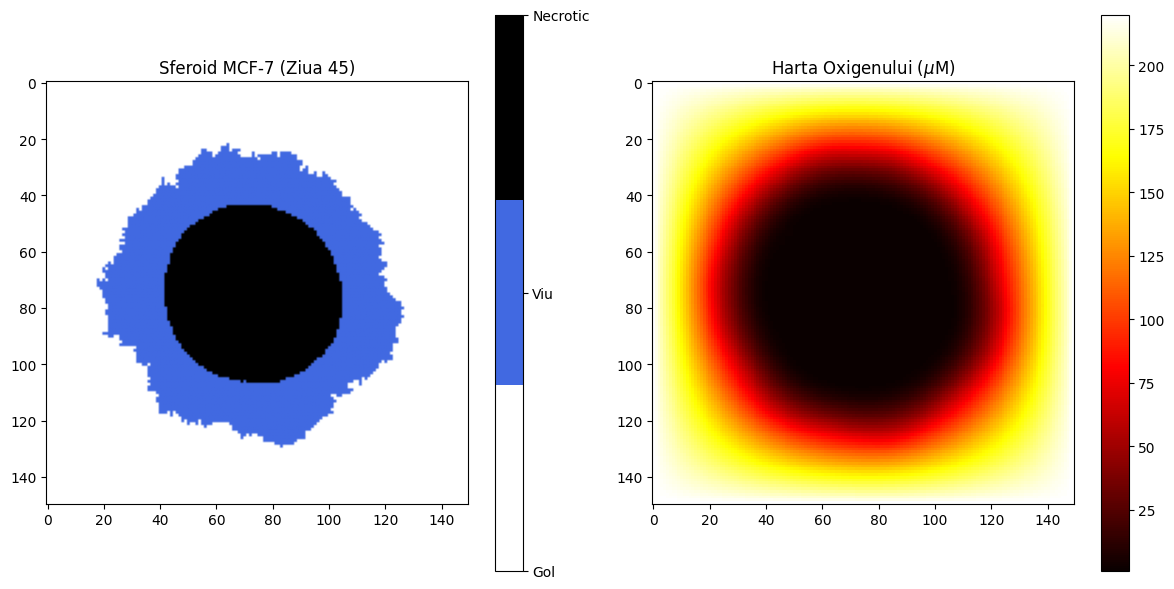

In [14]:
cmap_celule = mcolors.ListedColormap(['white', 'royalblue', 'black'])
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

im1 = ax[0].imshow(grid_celule, cmap=cmap_celule, vmin=0, vmax=2)
ax[0].set_title(f"Sferoid MCF-7 (Ziua {zile_de_simulat})")
fig.colorbar(im1, ax=ax[0], ticks=[0, 1, 2], format=plt.FuncFormatter(lambda val, loc: ['Gol', 'Viu', 'Necrotic'][val]))

im2 = ax[1].imshow(grid_oxigen, cmap='hot', interpolation='nearest')
ax[1].set_title("Harta Oxigenului ($\mu$M)")
fig.colorbar(im2, ax=ax[1])

plt.tight_layout()
plt.show()